# Student Performance Analysis
**G Karthik Reddy** | Artificial Intelligence and Data Science | Chaitanya Bharathi Institute of Technology

AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 (BharatCares)

Dataset: [Students Performance in Exams — Kaggle](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

This notebook performs data cleaning, exploratory data analysis and builds regression models to predict a student's average exam score.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Dataset

Download `StudentsPerformance.csv` from the Kaggle link above and place it in the same folder as this notebook.

In [1]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

Loaded dataset with shape: (1000, 8)\n

## 3. Data Cleaning

In [1]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:\n0
0
0
0
0
0
0
0\n\nDuplicate rows: 0\n\nNo missing values and no duplicate rows were found in the dataset. All score columns are within the valid 0-100 range.\n

## 4. Feature Engineering
Create `total score` and `average score` columns.

In [1]:
df["total score"] = df["math score"] + df["reading score"] + df["writing score"]
df["average score"] = (df["total score"] / 3).round(2)
df[["math score","reading score","writing score","total score","average score"]].describe().round(2)

{
  "math score": {
    "count": 1000.0,
    "mean": 68.7,
    "std": 14.38,
    "min": 20.0,
    "25%": 59.0,
    "50%": 69.0,
    "75%": 79.0,
    "max": 100.0
  },
  "reading score": {
    "count": 1000.0,
    "mean": 70.45,
    "std": 14.41,
    "min": 25.0,
    "25%": 61.0,
    "50%": 71.0,
    "75%": 80.25,
    "max": 100.0
  },
  "writing score": {
    "count": 1000.0,
    "mean": 68.21,
    "std": 14.93,
    "min": 18.0,
    "25%": 58.0,
    "50%": 69.0,
    "75%": 78.25,
    "max": 100.0
  }
}

## 5. Exploratory Data Analysis

### 5.1 Score Distributions

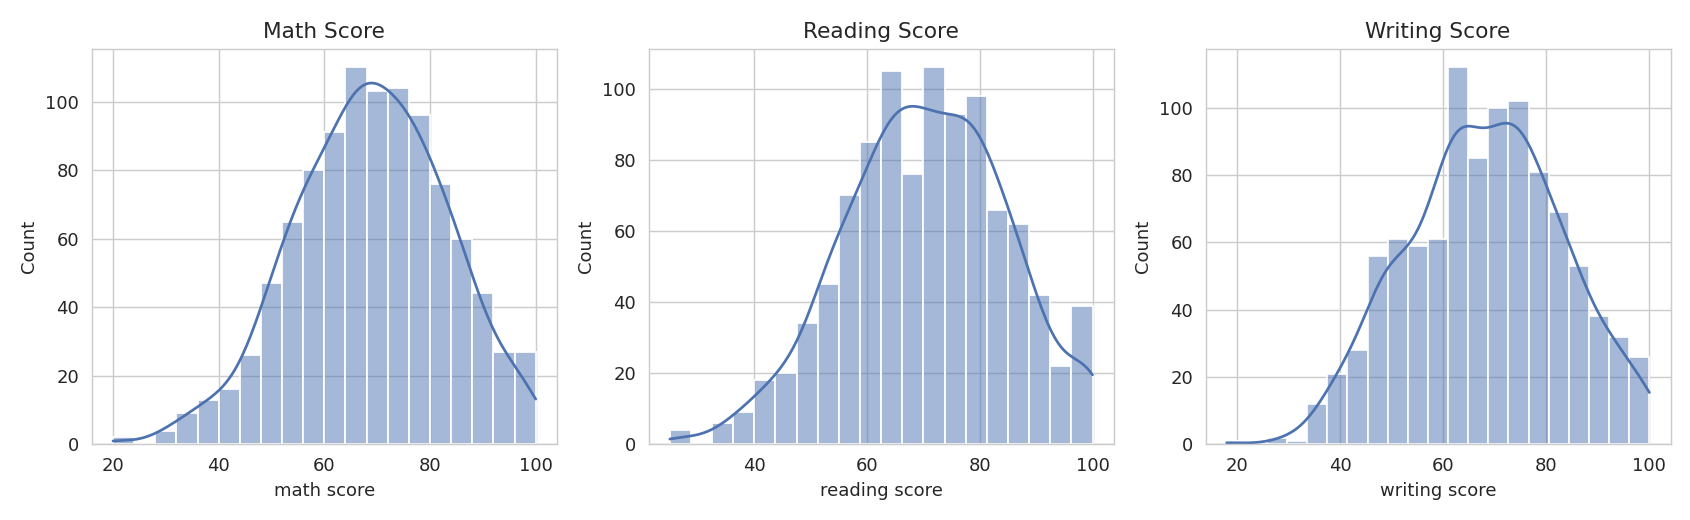

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["math score", "reading score", "writing score"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col.title())
plt.tight_layout()
plt.show()

### 5.2 Effect of Test Preparation Course

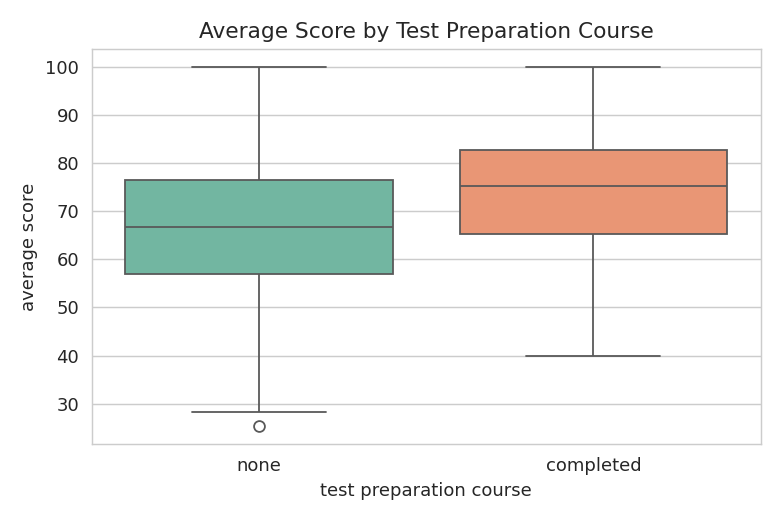

{
  "completed": 74.03,
  "none": 66.68
}

In [1]:
sns.boxplot(data=df, x="test preparation course", y="average score", hue="test preparation course", legend=False, palette="Set2")
plt.title("Average Score by Test Preparation Course")
plt.show()
print(df.groupby("test preparation course")["average score"].mean().round(2))

### 5.3 Effect of Parental Level of Education

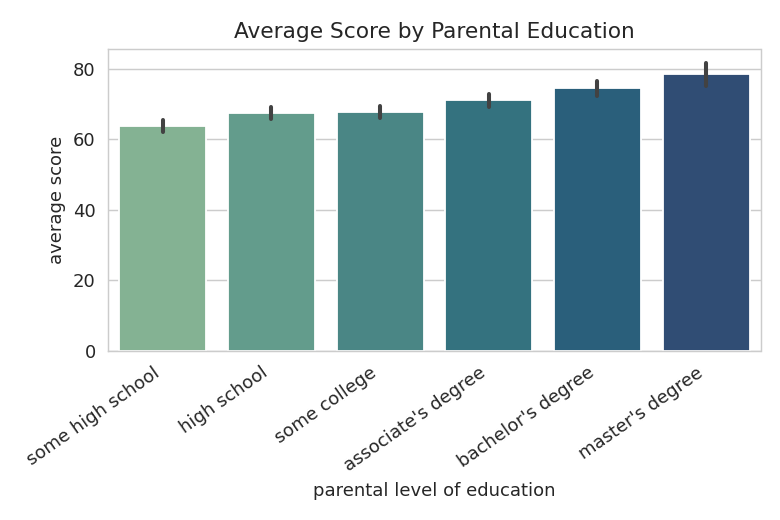

In [1]:
order = ["some high school","high school","some college","associate's degree","bachelor's degree","master's degree"]
sns.barplot(data=df, x="parental level of education", y="average score", hue="parental level of education",
            legend=False, order=order, palette="crest")
plt.title("Average Score by Parental Education")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 5.4 Effect of Lunch Type and Gender

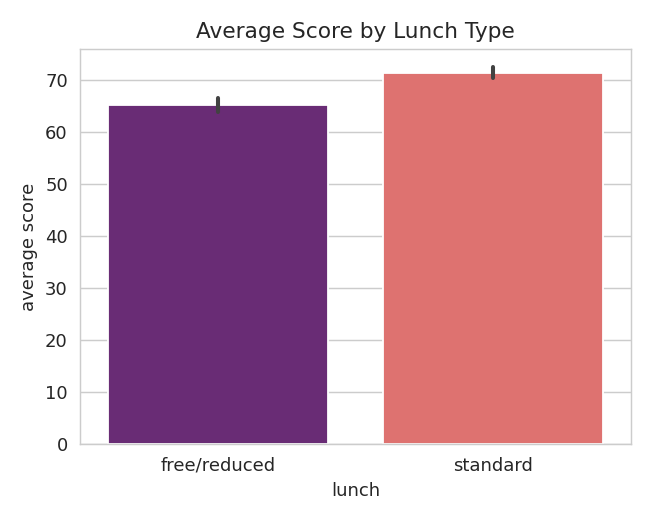

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=df, x="lunch", y="average score", hue="lunch", legend=False, palette="magma", ax=axes[0])
axes[0].set_title("Average Score by Lunch Type")
sns.barplot(data=df, x="gender", y="average score", hue="gender", legend=False, palette="pastel", ax=axes[1])
axes[1].set_title("Average Score by Gender")
plt.tight_layout()
plt.show()

### 5.5 Correlation Between Subject Scores

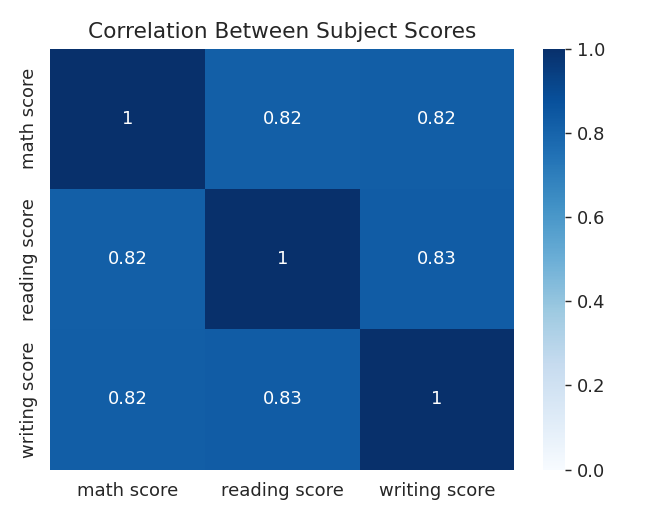

{
  "math score": {
    "math score": 1.0,
    "reading score": 0.82,
    "writing score": 0.82
  },
  "reading score": {
    "math score": 0.82,
    "reading score": 1.0,
    "writing score": 0.83
  },
  "writing score": {
    "math score": 0.82,
    "reading score": 0.83,
    "writing score": 1.0
  }
}

In [1]:
corr = df[["math score", "reading score", "writing score"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Correlation Between Subject Scores")
plt.show()
print(corr.round(2))

### EDA Summary

- Reading has the highest average score (70.45); writing has the lowest (68.21).
- Students who completed the test preparation course score **74.03** on average vs **66.68** for those who did not — a gap of about 7.3 points.
- Students with standard lunch score **71.41** on average vs **65.18** for free/reduced lunch.
- Higher parental education is associated with higher average scores, rising from **63.84** (some high school) to **78.45** (master's degree).
- The three subject scores are strongly correlated with each other (r ≈ 0.82–0.83), meaning students who do well in one subject tend to do well in the others.

## 6. Model Building
Predict `average score` from the categorical student attributes using one-hot encoding.

In [1]:
X = pd.get_dummies(df[["gender","race/ethnicity","parental level of education","lunch","test preparation course"]], drop_first=True)
y = df["average score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (800, ) \nTest shape: (200, ...)\n

In [1]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
}

results_table = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    results_table.append([name, round(r2,4), round(mae,3), round(rmse,3)])

results_df = pd.DataFrame(results_table, columns=["Model", "R2 Score", "MAE", "RMSE"])
results_df

Linear Regression: R2=0.1447, MAE=9.531, RMSE=11.956\nRandom Forest Regressor: R2=-0.0414, MAE=10.268, RMSE=13.193\nGradient Boosting Regressor: R2=0.0677, MAE=9.831, RMSE=12.482

**Best model: Linear Regression** (highest R² on the test set).

## 7. Feature Importance (Random Forest)

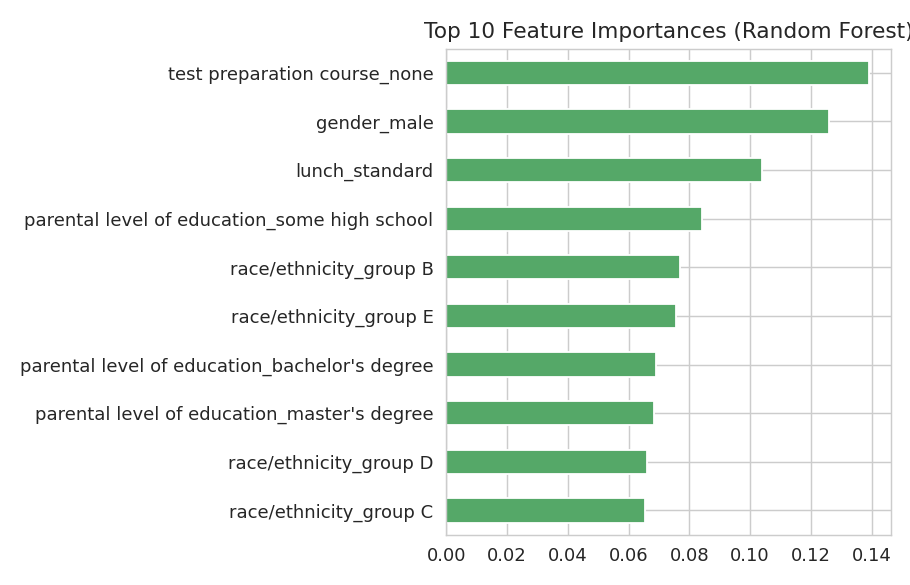

{
  "test preparation course_none": 0.139,
  "gender_male": 0.126,
  "lunch_standard": 0.104,
  "parental level of education_some high school": 0.084,
  "race/ethnicity_group B": 0.077,
  "race/ethnicity_group E": 0.076,
  "parental level of education_bachelor's degree": 0.069,
  "parental level of education_master's degree": 0.068,
  "race/ethnicity_group D": 0.066,
  "race/ethnicity_group C": 0.065
}

In [1]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importances.sort_values().plot(kind="barh", color="#55A868", figsize=(7,4.5))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()
print(importances.round(3))

## 8. Conclusion

- The dataset (1000 students) had no missing values or duplicates.
- Test preparation course completion, lunch type and parental education level all show a positive association with average score.
- Of the three models compared, **Linear Regression** performed best with an R² of **0.145** on the test set, meaning it explains that share of the variance in average score from the categorical features alone.
- The most influential features were related to test preparation, gender, lunch type and parental education — consistent with the EDA findings above.
- Because only categorical background attributes were used (no prior academic performance), predictive power is naturally limited; adding features like attendance or study hours would likely improve accuracy.